
# FamilyOWL difficulty vs accuracy analysis

This notebook:

- reads the **FamilyOWL** evaluated result files from `data/output/llm_results`
- computes correctness / partial correctness for the 3 LLMs:
  - `deepseek-chat`
  - `gpt-5-mini`
  - `llama-4-maverick`
- creates **30 histograms** total:
  - 5 parameters × 3 settings (`nl`, `ab`, `ttl`) × 2 hops (`1hop`, `2hop`)
- saves:
  - plot PNGs to `data/output/difficulty_accuracy_analysis_family/plots`
  - summary CSV tables to `data/output/difficulty_accuracy_analysis_family/tables`

## Parameters analyzed

1. **ABox size** — bins of width 10 (`0-9`, `10-19`, ...)
2. **Answer Type** — `BIN`, `MC`
3. **Task Type** — `Property Assertion`, `Membership`
4. **Min Tag Length** — bins `1,2,3,4,5,6,7,8+`
5. **Max Tag Length** — bins `1,2,3,4,5,6,7,8+`

## Scoring rule

- **BIN**: exact match after normalization → score is `1` or `0`
- **MC**:  
  score =  
  `(# correct answers mentioned by the model) / (# correct answers)`  

Example:

- ground truth: `abc; 1; aaa`
- model answer: `aaa; 4444; 1`

score = `2 / 3 = 0.666...`


In [1]:

from pathlib import Path
import re
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = False


## Configuration

In [2]:

# Optional manual override.
# Leave as None in the normal case.
MANUAL_PROJECT_ROOT = None  # e.g. r"C:\Users\abcma\OneDrive\Desktop\pro2\CORE-LLM-Bench-MasterProject2"


def find_project_root(manual_root=None) -> Path:
    '''
    Find the repo root robustly, even when the notebook is launched from scripts/analysis.
    We look upwards for a folder containing both:
    - pom.xml
    - data/
    '''
    if manual_root:
        root = Path(manual_root).expanduser().resolve()
        if not ((root / "pom.xml").exists() and (root / "data").exists()):
            raise FileNotFoundError(
                f"MANUAL_PROJECT_ROOT does not look like the repo root: {root}"
            )
        return root

    candidates = [Path.cwd().resolve()]
    seen = set()

    for candidate in candidates:
        for place in [candidate, *candidate.parents]:
            if place in seen:
                continue
            seen.add(place)
            if (place / "pom.xml").exists() and (place / "data").exists():
                return place

    raise FileNotFoundError(
        "Could not locate the project root automatically. "
        "Set MANUAL_PROJECT_ROOT in the configuration cell."
    )


PROJECT_ROOT = find_project_root(MANUAL_PROJECT_ROOT)
OUTPUT_ROOT = PROJECT_ROOT / "data" / "output"
LLM_RESULTS_ROOT = OUTPUT_ROOT / "llm_results"

ONTOLOGIES = ["FamilyOWL"]
HOPS = ["1hop", "2hop"]

SETTING_FILES = {
    "nl": "nl_results_FINAL.xlsx",
    "ab": "abstract_results_FINAL.xlsx",
    "ttl": "ttl_results_FINAL.xlsx",
}

ANALYSIS_DIR = OUTPUT_ROOT / "difficulty_accuracy_analysis_family"
PLOTS_DIR = ANALYSIS_DIR / "plots"
TABLES_DIR = ANALYSIS_DIR / "tables"

PLOTS_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

ABOX_BIN_WIDTH = 10
TAG_THRESHOLD_PLUS = 8

MODEL_FINAL_ANSWER_COLS = {
    "deepseek-chat": "deepseek-chat_final_answer",
    "gpt-5-mini": "gpt-5-mini_final_answer",
    "llama-4-maverick": "llama-4-maverick_final_answer",
}
MODEL_SCORE_COLS = {model: f"{model}_score" for model in MODEL_FINAL_ANSWER_COLS}

PARAMETERS = {
    "abox_size": {
        "source_col": "Size of ontology ABox",
        "title_label": "ABox size",
    },
    "answer_type": {
        "source_col": "Answer Type",
        "title_label": "Answer Type",
    },
    "task_type": {
        "source_col": "Task Type",
        "title_label": "Task Type",
    },
    "min_tag_length": {
        "source_col": "Min Tag Length",
        "title_label": "Min Tag Length",
    },
    "max_tag_length": {
        "source_col": "Max Tag Length",
        "title_label": "Max Tag Length",
    },
}

print("PROJECT_ROOT =", PROJECT_ROOT)
print("OUTPUT_ROOT  =", OUTPUT_ROOT)
print("LLM_RESULTS_ROOT =", LLM_RESULTS_ROOT)
print("PLOTS_DIR =", PLOTS_DIR)
print("TABLES_DIR =", TABLES_DIR)


PROJECT_ROOT = C:\Users\abcma\OneDrive\Desktop\pro2\CORE-LLM-Bench-MasterProject2
OUTPUT_ROOT  = C:\Users\abcma\OneDrive\Desktop\pro2\CORE-LLM-Bench-MasterProject2\data\output
LLM_RESULTS_ROOT = C:\Users\abcma\OneDrive\Desktop\pro2\CORE-LLM-Bench-MasterProject2\data\output\llm_results
PLOTS_DIR = C:\Users\abcma\OneDrive\Desktop\pro2\CORE-LLM-Bench-MasterProject2\data\output\difficulty_accuracy_analysis_family\plots
TABLES_DIR = C:\Users\abcma\OneDrive\Desktop\pro2\CORE-LLM-Bench-MasterProject2\data\output\difficulty_accuracy_analysis_family\tables


## Helper functions

In [3]:

def normalize_text(value):
    '''Return a cleaned string for comparison.'''
    if pd.isna(value):
        return ""
    text = str(value).strip()
    text = re.sub(r"^\s*(final answer|answer)\s*[:=\-]?\s*", "", text, flags=re.IGNORECASE)
    text = text.strip().strip('"').strip("'").strip()
    return text


def normalize_binary(value):
    '''Normalize binary answers to TRUE/FALSE when possible.'''
    text = normalize_text(value)
    upper = text.upper()

    if "TRUE" in upper:
        return "TRUE"
    if "FALSE" in upper:
        return "FALSE"

    if upper in {"T", "YES", "Y", "1"}:
        return "TRUE"
    if upper in {"F", "NO", "N", "0"}:
        return "FALSE"

    return upper


def split_mc_answers(value):
    '''
    Split MC answers into a normalized list using ';' as the main separator.
    Newlines are also treated like separators.
    '''
    text = normalize_text(value)
    if not text:
        return []

    text = text.replace("\n", ";")
    parts = [part.strip() for part in text.split(";")]

    cleaned = []
    for part in parts:
        part = part.strip().strip('"').strip("'").strip()
        part = re.sub(r"^\s*(final answer|answer)\s*[:=\-]?\s*", "", part, flags=re.IGNORECASE)
        if part:
            cleaned.append(part.casefold())

    # unique while preserving order
    unique_items = []
    seen = set()
    for item in cleaned:
        if item not in seen:
            unique_items.append(item)
            seen.add(item)

    return unique_items


def compute_row_score(ground_truth, prediction, answer_type):
    '''
    Score one row for one model.

    BIN:
        exact match after normalization -> 1 or 0

    MC:
        score = (# correctly matched answers) / (# correct answers)

    Example:
        GT   = "abc; 1; aaa"
        Pred = "aaa; 4444; 1"
        -> 2 / 3 = 0.666...
    '''
    answer_type = normalize_text(answer_type).upper()

    if answer_type == "BIN":
        return float(normalize_binary(ground_truth) == normalize_binary(prediction))

    gt_items = split_mc_answers(ground_truth)
    pred_items = set(split_mc_answers(prediction))

    if len(gt_items) == 0:
        return np.nan

    matched = sum(item in pred_items for item in gt_items)
    return matched / len(gt_items)


def add_model_scores(df):
    '''Add one score column per model.'''
    out = df.copy()

    required_base_cols = ["Task ID", "Answer", "Answer Type"]
    for col in required_base_cols:
        if col not in out.columns:
            raise KeyError(f"Missing expected base column: {col}")

    for model_name, pred_col in MODEL_FINAL_ANSWER_COLS.items():
        if pred_col not in out.columns:
            raise KeyError(f"Missing expected model-answer column: {pred_col}")

        score_col = MODEL_SCORE_COLS[model_name]
        out[score_col] = out.apply(
            lambda row: compute_row_score(
                ground_truth=row["Answer"],
                prediction=row[pred_col],
                answer_type=row["Answer Type"],
            ),
            axis=1,
        )

    return out


def abox_bin_label(value, width=10):
    if pd.isna(value):
        return np.nan
    value = int(value)
    start = (value // width) * width
    end = start + width - 1
    return f"{start}-{end}"


def tag_bin_label(value, threshold_plus=8):
    if pd.isna(value):
        return np.nan
    value = int(value)
    if value >= threshold_plus:
        return f"{threshold_plus}+"
    return str(value)


def get_parameter_bin_series(df, parameter_key):
    '''Return the bin/category series for the chosen parameter.'''
    source_col = PARAMETERS[parameter_key]["source_col"]

    if source_col not in df.columns:
        raise KeyError(f"Missing expected column for {parameter_key}: {source_col}")

    if parameter_key == "abox_size":
        return df[source_col].apply(lambda x: abox_bin_label(x, width=ABOX_BIN_WIDTH))

    if parameter_key == "answer_type":
        return df[source_col].astype(str).str.strip().str.upper()

    if parameter_key == "task_type":
        return df[source_col].astype(str).str.strip()

    if parameter_key in {"min_tag_length", "max_tag_length"}:
        return df[source_col].apply(lambda x: tag_bin_label(x, threshold_plus=TAG_THRESHOLD_PLUS))

    raise ValueError(f"Unknown parameter_key: {parameter_key}")


def get_bin_order(values, parameter_key):
    '''Return the plotting order for the bins of one parameter.'''
    values = pd.Series(values).dropna().astype(str)
    unique_values = list(pd.unique(values))

    if parameter_key == "abox_size":
        return sorted(unique_values, key=lambda x: int(x.split("-")[0]))

    if parameter_key == "answer_type":
        preferred = ["BIN", "MC"]
        return [x for x in preferred if x in unique_values] + [x for x in sorted(unique_values) if x not in preferred]

    if parameter_key == "task_type":
        preferred = ["Property Assertion", "Membership"]
        return [x for x in preferred if x in unique_values] + [x for x in sorted(unique_values) if x not in preferred]

    if parameter_key in {"min_tag_length", "max_tag_length"}:
        ordered = [str(i) for i in range(1, TAG_THRESHOLD_PLUS) if str(i) in unique_values]
        plus_label = f"{TAG_THRESHOLD_PLUS}+"
        if plus_label in unique_values:
            ordered.append(plus_label)

        leftovers = [x for x in unique_values if x not in ordered]

        def tag_sort_key(x):
            if x.endswith("+"):
                return (10**9, x)
            try:
                return (int(x), x)
            except ValueError:
                return (10**8, x)

        if leftovers:
            ordered.extend(sorted(leftovers, key=tag_sort_key))

        return ordered

    return sorted(unique_values)


def build_accuracy_table(df, parameter_key):
    '''
    Build one aggregated table for one parameter:
    - count per bin
    - per-model accuracy
    - overall accuracy = average of the 3 model accuracies
    '''
    work = df.copy()
    work["_bin"] = get_parameter_bin_series(work, parameter_key)

    bin_order = get_bin_order(work["_bin"], parameter_key)

    rows = []
    for bin_value in bin_order:
        subset = work[work["_bin"] == bin_value].copy()
        if subset.empty:
            continue

        row = {
            "bin": bin_value,
            "count": int(subset["Task ID"].nunique()) if "Task ID" in subset.columns else int(len(subset)),
        }

        for model_name in MODEL_FINAL_ANSWER_COLS:
            row[model_name] = subset[MODEL_SCORE_COLS[model_name]].mean()

        row["overall_accuracy"] = np.nanmean([row[m] for m in MODEL_FINAL_ANSWER_COLS])
        rows.append(row)

    return pd.DataFrame(rows)


def plot_accuracy_histogram(
    agg_df,
    ontology_name,
    hop,
    setting,
    parameter_key,
    save_path=None,
    show_plot=True,
):
    '''
    Create one histogram:
    - bar height = average accuracy across the 3 LLMs
    - dots = per-model accuracy
    - x-axis labels include (n=...)
    '''
    if agg_df.empty:
        print(f"Skipping empty plot: {ontology_name} / {hop} / {setting} / {parameter_key}")
        return None

    parameter_label = PARAMETERS[parameter_key]["title_label"]

    extra = ""
    if parameter_key == "abox_size":
        extra = f"bin width = {ABOX_BIN_WIDTH}"
    elif parameter_key in {"min_tag_length", "max_tag_length"}:
        extra = f"bins: 1-{TAG_THRESHOLD_PLUS - 1}, {TAG_THRESHOLD_PLUS}+"

    fig, ax = plt.subplots(figsize=(10, 6))
    x = np.arange(len(agg_df))

    # overall bar
    ax.bar(x, agg_df["overall_accuracy"], alpha=0.35, label="overall accuracy")

    # model dots
    for model_name in MODEL_FINAL_ANSWER_COLS:
        ax.scatter(
            x,
            agg_df[model_name],
            s=80,
            label=model_name,
            zorder=3,
        )

    xticklabels = [f"{bin_label}\n(n={count})" for bin_label, count in zip(agg_df["bin"], agg_df["count"])]
    ax.set_xticks(x)
    ax.set_xticklabels(xticklabels)

    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Accuracy")
    ax.set_xlabel(f"{parameter_label}\n(n = query count)")
    title = f"{ontology_name} — {hop} — {setting}\nAccuracy by {parameter_label}"
    if extra:
        title += f" ({extra})"
    ax.set_title(title)

    ax.grid(axis="y", alpha=0.25)

    handles, labels = ax.get_legend_handles_labels()
    seen = set()
    unique_handles = []
    unique_labels = []
    for handle, label in zip(handles, labels):
        if label not in seen:
            unique_handles.append(handle)
            unique_labels.append(label)
            seen.add(label)

    ax.legend(unique_handles, unique_labels, loc="best")
    fig.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=150, bbox_inches="tight")

    if show_plot:
        plt.show()
    else:
        plt.close(fig)

    return fig


def find_result_file(ontology_name, hop, setting):
    folder = LLM_RESULTS_ROOT / f"{ontology_name}_{hop}"
    filename = SETTING_FILES[setting]
    path = folder / filename
    if not path.exists():
        raise FileNotFoundError(f"Could not find file: {path}")
    return path


def load_result_file(file_path):
    '''Read one evaluated result file.'''
    file_path = Path(file_path)
    if file_path.suffix.lower() in {".xlsx", ".xls"}:
        df = pd.read_excel(file_path)
    elif file_path.suffix.lower() == ".csv":
        df = pd.read_csv(file_path)
    else:
        raise ValueError(f"Unsupported file type: {file_path.suffix}")

    df.columns = [str(col).strip() for col in df.columns]
    return df


def list_expected_files():
    rows = []
    for ontology_name in ONTOLOGIES:
        for hop in HOPS:
            for setting, filename in SETTING_FILES.items():
                path = LLM_RESULTS_ROOT / f"{ontology_name}_{hop}" / filename
                rows.append(
                    {
                        "ontology": ontology_name,
                        "hop": hop,
                        "setting": setting,
                        "path": str(path),
                        "exists": path.exists(),
                    }
                )
    return pd.DataFrame(rows)


## Quick scoring sanity check

In [4]:

print("BIN example 1:", compute_row_score("TRUE", "FALSE", "BIN"))
print("BIN example 2:", compute_row_score("TRUE", "Answer: TRUE", "BIN"))
print("MC example  :", compute_row_score("abc; 1; aaa", "aaa; 4444; 1", "MC"))  # expected 2/3


BIN example 1: 0.0
BIN example 2: 1.0
MC example  : 0.6666666666666666


## Check that the expected FamilyOWL files exist

In [5]:

expected_files_df = list_expected_files()
display(expected_files_df)


,ontology,hop,setting,path,exists
0,FamilyOWL,1hop,nl,C:\Users\abcma\OneDrive\Desktop\pro2\CORE-LLM-...,True
1,FamilyOWL,1hop,ab,C:\Users\abcma\OneDrive\Desktop\pro2\CORE-LLM-...,True
2,FamilyOWL,1hop,ttl,C:\Users\abcma\OneDrive\Desktop\pro2\CORE-LLM-...,True
3,FamilyOWL,2hop,nl,C:\Users\abcma\OneDrive\Desktop\pro2\CORE-LLM-...,True
4,FamilyOWL,2hop,ab,C:\Users\abcma\OneDrive\Desktop\pro2\CORE-LLM-...,True
5,FamilyOWL,2hop,ttl,C:\Users\abcma\OneDrive\Desktop\pro2\CORE-LLM-...,True


## Main run function

In [6]:

def run_familyowl_analysis(show_plots=False, save_tables=True):
    '''
    Run the full analysis for FamilyOWL.
    Returns:
        {
            "plots": [Path, ...],
            "tables": [Path, ...],
            "long_df": pandas.DataFrame,
        }
    '''
    generated_plot_paths = []
    generated_table_paths = []
    long_rows = []

    PLOTS_DIR.mkdir(parents=True, exist_ok=True)
    TABLES_DIR.mkdir(parents=True, exist_ok=True)

    print("Saving plots to:", PLOTS_DIR)
    print("Saving tables to:", TABLES_DIR)

    for ontology_name in ONTOLOGIES:
        for hop in HOPS:
            for setting in SETTING_FILES:
                file_path = find_result_file(ontology_name, hop, setting)
                print(f"\nReading: {file_path}")

                df = load_result_file(file_path)
                df = add_model_scores(df)

                # long-form row table (one row per task x model)
                for model_name in MODEL_FINAL_ANSWER_COLS:
                    keep_cols = [
                        "Task ID",
                        "Root Entity",
                        "Size of ontology TBox",
                        "Size of ontology ABox",
                        "Task Type",
                        "Answer Type",
                        "SPARQL Query",
                        "Predicate",
                        "Answer",
                        "Min Tag Length",
                        "Max Tag Length",
                        MODEL_FINAL_ANSWER_COLS[model_name],
                        MODEL_SCORE_COLS[model_name],
                    ]
                    keep_cols = [c for c in keep_cols if c in df.columns]

                    tmp = df[keep_cols].copy()
                    tmp["ontology"] = ontology_name
                    tmp["hop"] = hop
                    tmp["setting"] = setting
                    tmp["model"] = model_name
                    tmp = tmp.rename(
                        columns={
                            MODEL_FINAL_ANSWER_COLS[model_name]: "model_final_answer",
                            MODEL_SCORE_COLS[model_name]: "score",
                        }
                    )
                    long_rows.append(tmp)

                # aggregated tables + plots
                for parameter_key in PARAMETERS:
                    agg_df = build_accuracy_table(df, parameter_key)

                    if save_tables:
                        table_path = TABLES_DIR / f"{ontology_name}_{hop}_{setting}_{parameter_key}_accuracy_table.csv"
                        agg_df.to_csv(table_path, index=False)
                        generated_table_paths.append(table_path)

                    plot_path = PLOTS_DIR / f"{ontology_name}_{hop}_{setting}_{parameter_key}_accuracy.png"
                    plot_accuracy_histogram(
                        agg_df=agg_df,
                        ontology_name=ontology_name,
                        hop=hop,
                        setting=setting,
                        parameter_key=parameter_key,
                        save_path=plot_path,
                        show_plot=show_plots,
                    )
                    generated_plot_paths.append(plot_path)

    if long_rows:
        long_df = pd.concat(long_rows, ignore_index=True)
        long_df_path = TABLES_DIR / "familyowl_long_scores.csv"
        if save_tables:
            long_df.to_csv(long_df_path, index=False)
            generated_table_paths.append(long_df_path)
    else:
        long_df = pd.DataFrame()

    actual_pngs = sorted(PLOTS_DIR.glob("*.png"))

    print(f"\nRequested plot count : {len(generated_plot_paths)}")
    print(f"Actual saved PNG count: {len(actual_pngs)}")
    print(f"Generated table count : {len(generated_table_paths)}")

    if len(actual_pngs) != len(generated_plot_paths):
        print("Warning: requested plot count and saved PNG count differ.")

    return {
        "plots": actual_pngs,
        "tables": generated_table_paths,
        "long_df": long_df,
    }


## Run the full analysis

In [7]:

results = run_familyowl_analysis(show_plots=False, save_tables=True)

print("\nFirst 10 saved plot files:")
for p in results["plots"][:10]:
    print(" ", p.name)

print("\nLong-form score table shape:")
print(results["long_df"].shape)


Saving plots to: C:\Users\abcma\OneDrive\Desktop\pro2\CORE-LLM-Bench-MasterProject2\data\output\difficulty_accuracy_analysis_family\plots
Saving tables to: C:\Users\abcma\OneDrive\Desktop\pro2\CORE-LLM-Bench-MasterProject2\data\output\difficulty_accuracy_analysis_family\tables

Reading: C:\Users\abcma\OneDrive\Desktop\pro2\CORE-LLM-Bench-MasterProject2\data\output\llm_results\FamilyOWL_1hop\nl_results_FINAL.xlsx

Reading: C:\Users\abcma\OneDrive\Desktop\pro2\CORE-LLM-Bench-MasterProject2\data\output\llm_results\FamilyOWL_1hop\abstract_results_FINAL.xlsx

Reading: C:\Users\abcma\OneDrive\Desktop\pro2\CORE-LLM-Bench-MasterProject2\data\output\llm_results\FamilyOWL_1hop\ttl_results_FINAL.xlsx

Reading: C:\Users\abcma\OneDrive\Desktop\pro2\CORE-LLM-Bench-MasterProject2\data\output\llm_results\FamilyOWL_2hop\nl_results_FINAL.xlsx

Reading: C:\Users\abcma\OneDrive\Desktop\pro2\CORE-LLM-Bench-MasterProject2\data\output\llm_results\FamilyOWL_2hop\abstract_results_FINAL.xlsx

Reading: C:\Users\

## Show the saved plot files

In [8]:

saved_plot_files = sorted(PLOTS_DIR.glob("*.png"))
print("PLOTS_DIR =", PLOTS_DIR)
print("PNG count =", len(saved_plot_files))

for p in saved_plot_files:
    print(p.name)


PLOTS_DIR = C:\Users\abcma\OneDrive\Desktop\pro2\CORE-LLM-Bench-MasterProject2\data\output\difficulty_accuracy_analysis_family\plots
PNG count = 30
FamilyOWL_1hop_ab_abox_size_accuracy.png
FamilyOWL_1hop_ab_answer_type_accuracy.png
FamilyOWL_1hop_ab_max_tag_length_accuracy.png
FamilyOWL_1hop_ab_min_tag_length_accuracy.png
FamilyOWL_1hop_ab_task_type_accuracy.png
FamilyOWL_1hop_nl_abox_size_accuracy.png
FamilyOWL_1hop_nl_answer_type_accuracy.png
FamilyOWL_1hop_nl_max_tag_length_accuracy.png
FamilyOWL_1hop_nl_min_tag_length_accuracy.png
FamilyOWL_1hop_nl_task_type_accuracy.png
FamilyOWL_1hop_ttl_abox_size_accuracy.png
FamilyOWL_1hop_ttl_answer_type_accuracy.png
FamilyOWL_1hop_ttl_max_tag_length_accuracy.png
FamilyOWL_1hop_ttl_min_tag_length_accuracy.png
FamilyOWL_1hop_ttl_task_type_accuracy.png
FamilyOWL_2hop_ab_abox_size_accuracy.png
FamilyOWL_2hop_ab_answer_type_accuracy.png
FamilyOWL_2hop_ab_max_tag_length_accuracy.png
FamilyOWL_2hop_ab_min_tag_length_accuracy.png
FamilyOWL_2hop_ab_ta

## Optional: display a few sample plots inside the notebook


 FamilyOWL_1hop_nl_abox_size_accuracy.png


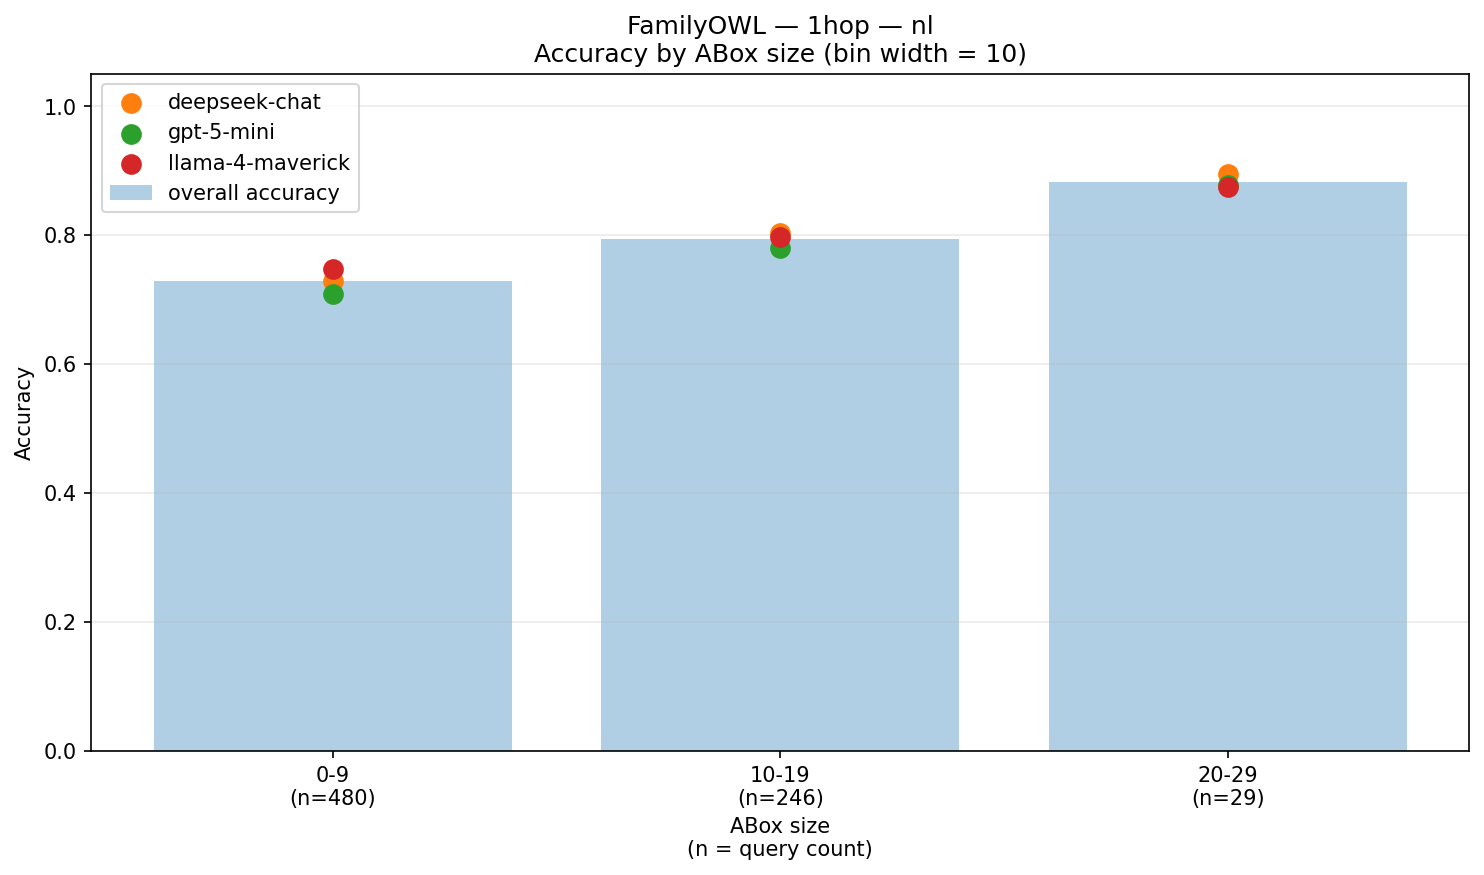


 FamilyOWL_1hop_ttl_answer_type_accuracy.png


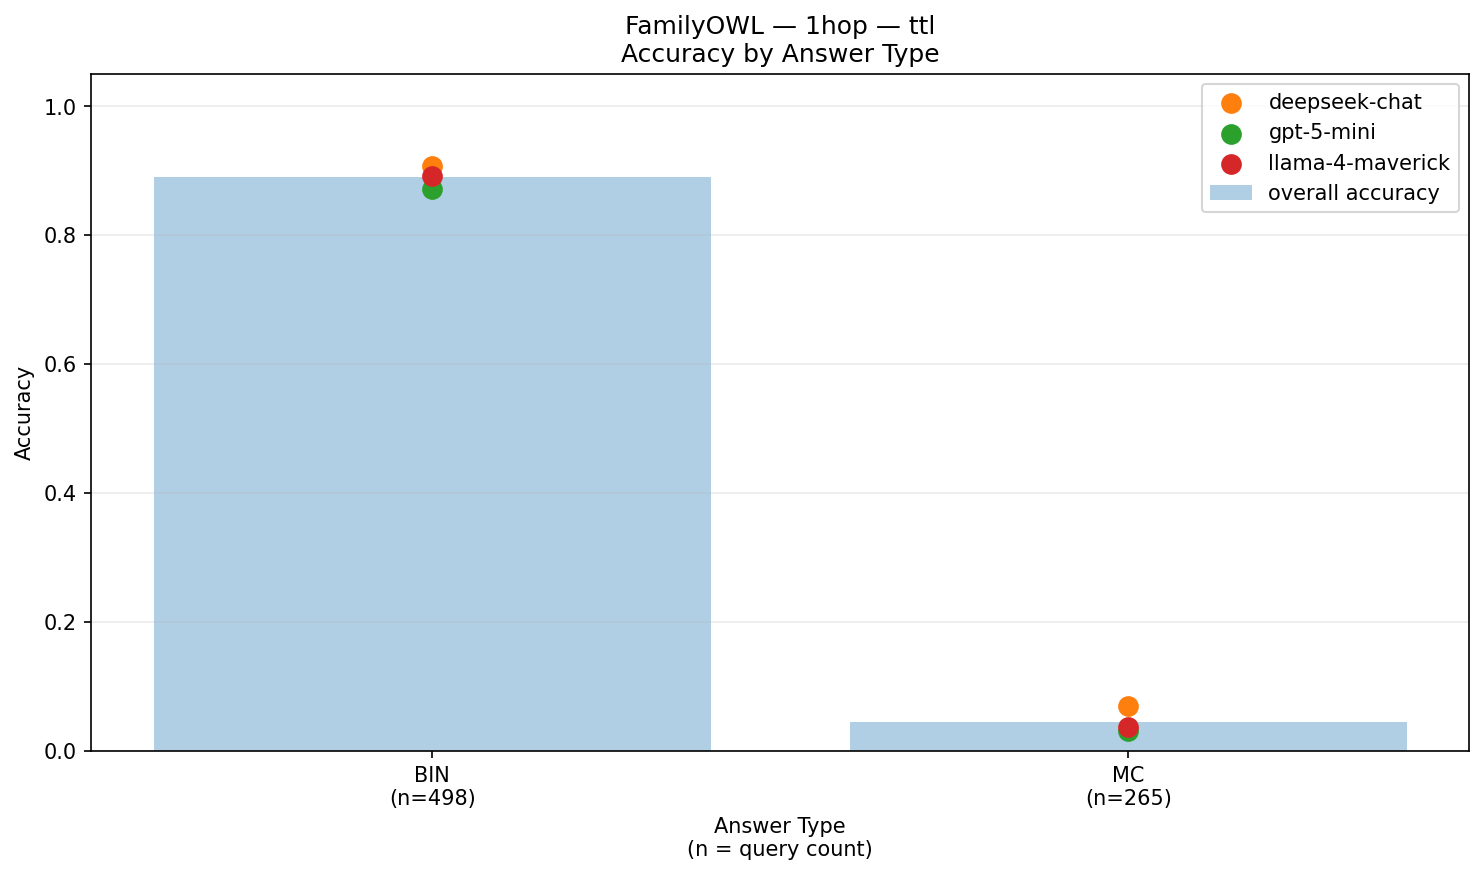


 FamilyOWL_2hop_ab_max_tag_length_accuracy.png


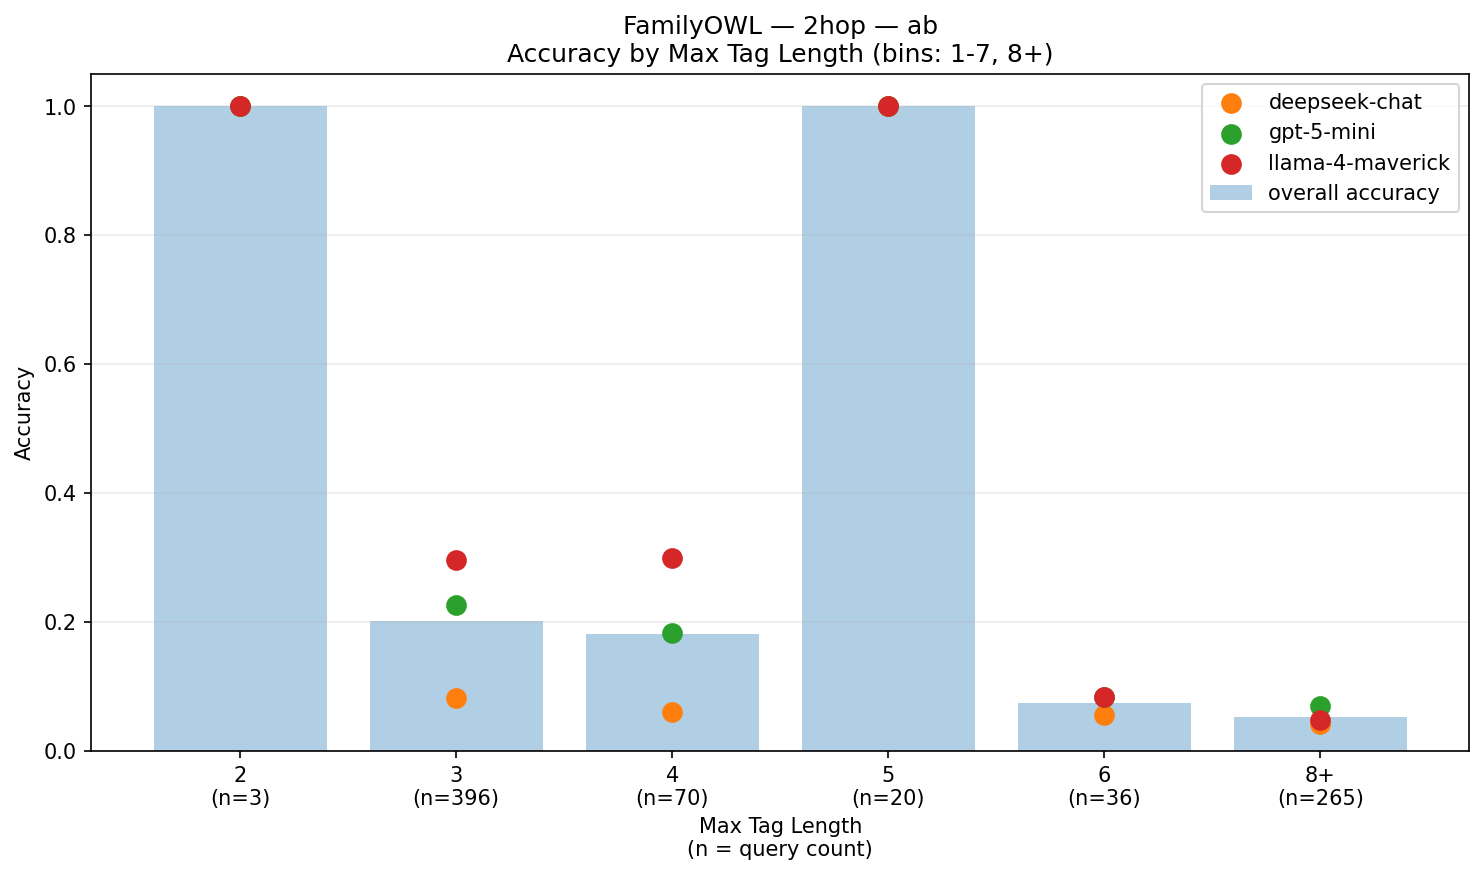

In [9]:

sample_specs = [
    ("FamilyOWL", "1hop", "nl", "abox_size"),
    ("FamilyOWL", "1hop", "ttl", "answer_type"),
    ("FamilyOWL", "2hop", "ab", "max_tag_length"),
]

for ontology_name, hop, setting, parameter_key in sample_specs:
    img_path = PLOTS_DIR / f"{ontology_name}_{hop}_{setting}_{parameter_key}_accuracy.png"
    print("\n", img_path.name)
    display(Image(filename=str(img_path)))


## Optional: display all 30 saved plots

In [10]:

DISPLAY_ALL_PLOTS = False

if DISPLAY_ALL_PLOTS:
    for p in sorted(PLOTS_DIR.glob("*.png")):
        print("\n", p.name)
        display(Image(filename=str(p)))
else:
    print("Set DISPLAY_ALL_PLOTS = True if you want to display all saved plots here.")


Set DISPLAY_ALL_PLOTS = True if you want to display all saved plots here.


## Optional: inspect the long-form table

In [11]:

results["long_df"].head()


,Task ID,Root Entity,Size of ontology TBox,Size of ontology ABox,Task Type,Answer Type,SPARQL Query,Predicate,Answer,Min Tag Length,Max Tag Length,model_final_answer,score,ontology,hop,setting,model
0,1hop-Thing_ada_rachel_heath_1868_gwendoline_he...,Thing_ada_rachel_heath_1868,51,5,Membership,MC,SELECT ?x WHERE { <http://www.example.com/gene...,rdf:type,Domain Entity; Person,7,13,Person,0.5,FamilyOWL,1hop,nl,deepseek-chat
1,1hop-Thing_ada_rachel_heath_1868_gwendoline_he...,Thing_ada_rachel_heath_1868,51,5,Membership,BIN,ASK WHERE { <http://www.example.com/genealogy....,rdf:type,True,2,5,True,1.0,FamilyOWL,1hop,nl,deepseek-chat
2,1hop-Thing_ada_rachel_heath_1868_m135-m135-has...,Thing_ada_rachel_heath_1868,51,5,Property Assertion,BIN,ASK WHERE { <http://www.example.com/genealogy....,hasFemalePartner,True,1,3,True,1.0,FamilyOWL,1hop,nl,deepseek-chat
3,1hop-Thing_ada_steward_1871_john_tacey_steward...,Thing_ada_steward_1871,51,5,Property Assertion,BIN,ASK WHERE { <http://www.example.com/genealogy....,hasSister,True,1,3,True,1.0,FamilyOWL,1hop,nl,deepseek-chat
4,1hop-Thing_ada_steward_1871_james_steward_1830...,Thing_ada_steward_1871,51,5,Property Assertion,BIN,ASK WHERE { <http://www.example.com/genealogy....,isSiblingOf,True,3,3,False,0.0,FamilyOWL,1hop,nl,deepseek-chat
